In [65]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable
from torchvision.utils import save_image

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [66]:
BATCH_SIZE = 256

# MNIST Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))])

train_dataset = datasets.MNIST(root='data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='data', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [67]:
hidden_dimension = 128

def init_weights(m):
    if type(m) == torch.nn.Linear:
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)

class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, hidden_dim)
        self.dropout = nn.Dropout(0.2)
        self.apply(init_weights)

    # forward method
    def forward(self, x):
        x = F.leaky_relu(self.fc1(x), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.fc2(x), 0.2)
        x = self.dropout(x)
        return torch.tanh(self.fc3(x))

class Decoder(nn.Module):
    def __init__(self, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(hidden_dim, 128)
        self.fc2 = nn.Linear(128, 256)
        self.fc3 = nn.Linear(256, output_dim)
        self.dropout = nn.Dropout(0.2)
        self.apply(init_weights)

    # forward method
    def forward(self, x):
        x = F.leaky_relu(self.fc1(x), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.fc2(x), 0.2)
        x = self.dropout(x)
        return torch.tanh(self.fc3(x))

In [68]:
Z_DIM = 32
mnist_dim = train_dataset.train_data.size(1) * train_dataset.train_data.size(2)

print (f'mnist_dim = {mnist_dim}')

E = Encoder(input_dim = mnist_dim, hidden_dim = Z_DIM).to(device)
D = Decoder(hidden_dim=Z_DIM, output_dim=mnist_dim).to(device)

mnist_dim = 784


In [69]:
E

Encoder(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=32, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

In [70]:
D

Decoder(
  (fc1): Linear(in_features=32, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=784, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)

In [71]:
# loss
criterion = nn.MSELoss()

# optimizer
lr = 0.001
E_optimizer = optim.Adam(E.parameters(), lr = lr)
D_optimizer = optim.Adam(D.parameters(), lr = lr)

In [72]:
def D_train(x):
    D.zero_grad()
    E.zero_grad()

    # train decoder on reconstruction
    x_real = x.view(-1, mnist_dim)
    x_real = Variable(x_real.to(device))

    # Encode first (using encoder)
    hidden_vectors = E(x_real)

    # Decode back (this is what we train)
    reconstructed = D(hidden_vectors)

    # Calculate reconstruction loss - how close to original
    D_loss = criterion(reconstructed, x_real)

    # gradient backprop & optimize ONLY decoder's parameters
    D_loss.backward()
    D_optimizer.step()

    return D_loss.data.item()

def E_train(x):
    D.zero_grad()
    E.zero_grad()

    # train encoder on good representations
    x_real = x.view(-1, mnist_dim)
    x_real = Variable(x_real.to(device))

    # Encode (this is what we train)
    hidden_vectors = E(x_real)

    # Decode back (using decoder)
    reconstructed = D(hidden_vectors)

    # Calculate reconstruction loss - how good is the encoding
    E_loss = criterion(reconstructed, x_real)

    # gradient backprop & optimize ONLY encoder's parameters
    E_loss.backward()
    E_optimizer.step()

    return E_loss.data.item()

In [73]:
test_z = Variable(torch.randn(BATCH_SIZE, Z_DIM).to(device))

def generate_test_image(epoch):
    with torch.no_grad():
        generated_flat = D(test_z)
        generated = generated_flat.view(BATCH_SIZE, 1, 28, 28)
        save_image(generated[:16], f'./samples/sample_epoch_{epoch}.png',
                  nrow=4, normalize=True)

In [74]:
import os
os.makedirs('./samples', exist_ok=True)
n_epoch = 100
D_losses, E_losses = [], []

for epoch in range(1, n_epoch+1):
    for batch_idx, (x, _) in enumerate(train_loader):
        D_losses.append(D_train(x))
        E_losses.append(E_train(x))

    print('[%d/%d]: loss_d: %.3f, loss_e: %.3f' % (
        epoch, n_epoch,
        torch.mean(torch.FloatTensor(D_losses)),
        torch.mean(torch.FloatTensor(E_losses))))

    if (epoch + 1) % 5 == 0:
        generate_test_image(epoch)

[1/100]: loss_d: 0.270, loss_e: 0.266
[2/100]: loss_d: 0.207, loss_e: 0.205
[3/100]: loss_d: 0.175, loss_e: 0.174
[4/100]: loss_d: 0.157, loss_e: 0.156
[5/100]: loss_d: 0.144, loss_e: 0.143
[6/100]: loss_d: 0.135, loss_e: 0.134
[7/100]: loss_d: 0.128, loss_e: 0.127
[8/100]: loss_d: 0.122, loss_e: 0.121
[9/100]: loss_d: 0.117, loss_e: 0.117
[10/100]: loss_d: 0.114, loss_e: 0.113
[11/100]: loss_d: 0.110, loss_e: 0.110
[12/100]: loss_d: 0.107, loss_e: 0.107
[13/100]: loss_d: 0.105, loss_e: 0.104
[14/100]: loss_d: 0.103, loss_e: 0.102
[15/100]: loss_d: 0.101, loss_e: 0.100
[16/100]: loss_d: 0.099, loss_e: 0.099
[17/100]: loss_d: 0.097, loss_e: 0.097
[18/100]: loss_d: 0.096, loss_e: 0.095
[19/100]: loss_d: 0.094, loss_e: 0.094
[20/100]: loss_d: 0.093, loss_e: 0.093
[21/100]: loss_d: 0.092, loss_e: 0.092
[22/100]: loss_d: 0.091, loss_e: 0.091
[23/100]: loss_d: 0.090, loss_e: 0.090
[24/100]: loss_d: 0.089, loss_e: 0.089
[25/100]: loss_d: 0.088, loss_e: 0.088
[26/100]: loss_d: 0.087, loss_e: 0

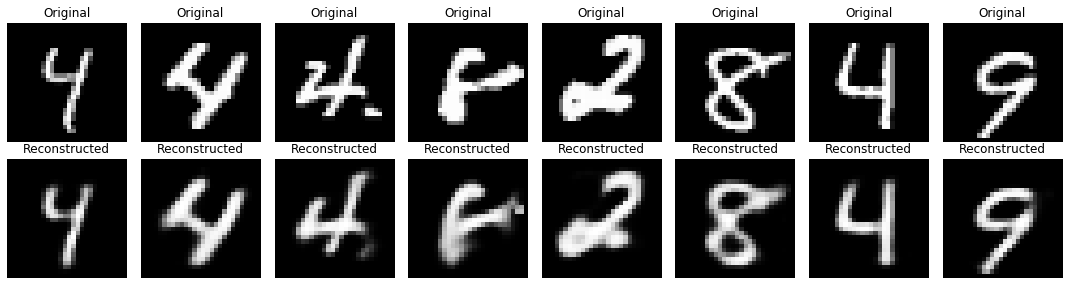

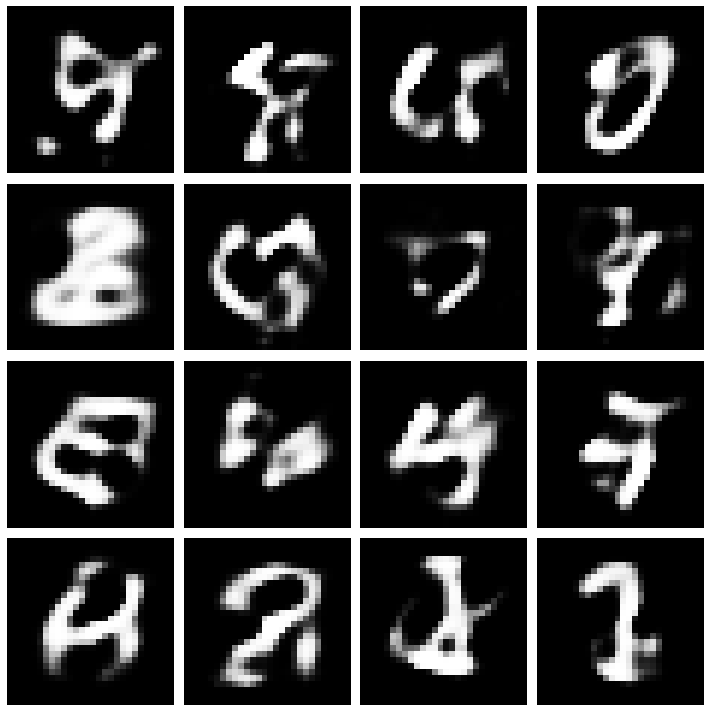

In [77]:
import matplotlib.pyplot as plt
def visualize_results():
    E.eval()
    D.eval()
    with torch.no_grad():
        test_data, _ = next(iter(train_loader))
        test_data = test_data[:8].to(device)

        test_flat = test_data.view(-1, mnist_dim)
        latent = E(test_flat)
        reconstructed_flat = D(latent)
        reconstructed = reconstructed_flat.view(8, 1, 28, 28)

        fig, axes = plt.subplots(2, 8, figsize=(15, 4))
        for i in range(8):
            axes[0, i].imshow(test_data[i].cpu().squeeze(), cmap='gray')
            axes[0, i].set_title('Original')
            axes[0, i].axis('off')
            axes[1, i].imshow(reconstructed[i].cpu().squeeze(), cmap='gray')
            axes[1, i].set_title('Reconstructed')
            axes[1, i].axis('off')
        plt.tight_layout()
        plt.show()

        # Генерация из случайных векторов
        random_z = torch.randn(16, Z_DIM).to(device)
        generated_flat = D(random_z)
        generated = generated_flat.view(16, 1, 28, 28)

        plt.figure(figsize=(10, 10))
        for i in range(16):
            plt.subplot(4, 4, i+1)
            plt.imshow(generated[i].cpu().squeeze(), cmap='gray')
            plt.axis('off')
        plt.tight_layout()
        plt.show()

visualize_results()

# Сохранение моделей
torch.save(E.state_dict(), 'encoder_final.pth')
torch.save(D.state_dict(), 'decoder_final.pth')